Loaded 3984 samples | Classes: {'dementia': 2048, 'control': 1936}
Features extracted: 18 features × 3984 samples

Feature                  Dementia    Control    Diff%
-------------------------------------------------------
  ttr                      0.6401     0.6495     -1.5%
  filler_rate              0.0352     0.0101   +250.6%
  repetition_rate          0.0143     0.0051   +181.8%
  iu_density               0.1092     0.1203     -9.2%
  pronoun_rate             0.0606     0.0457    +32.6%
  mean_sent_len            8.7420     9.0737     -3.7%
  brunet                   9.9053     9.9996     -0.9%
  verb_rate                0.0678     0.0900    -24.7%

Original : 3984 | Augmented : 7968 | Total : 11952

Logistic Regression
  No aug  → Acc:0.823  F1:0.824  AUC:0.911  Prec:0.839  Rec:0.810
  With aug→ Acc:0.839  F1:0.841  AUC:0.924  Prec:0.857  Rec:0.825

SVM (RBF)
  No aug  → Acc:0.915  F1:0.915  AUC:0.965  Prec:0.941  Rec:0.890
  With aug→ Acc:0.949  F1:0.949  AUC:0.985  Prec:0.97

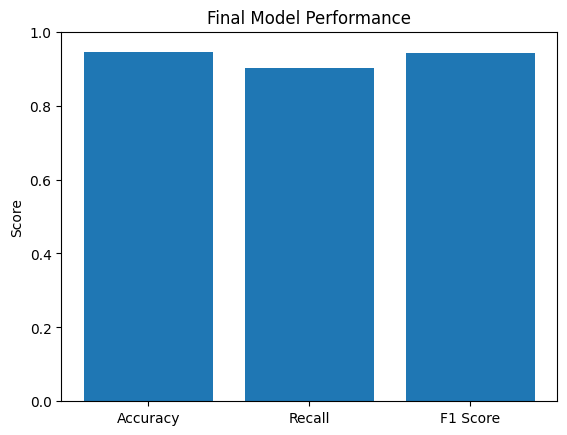

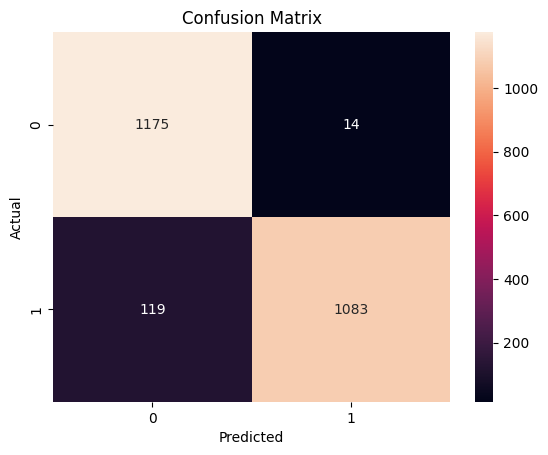

AUC Score: 0.9879


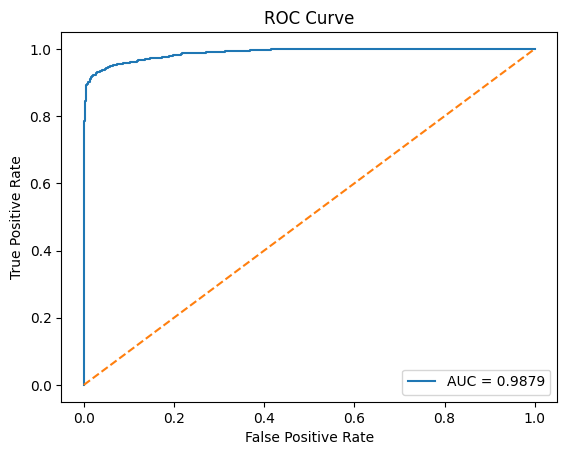

In [6]:
"""
Dementia Detection Pipeline — Cookie Theft Task
================================================
Features:
  - Linguistic feature extraction
  - EDA-style synthetic augmentation
  - 5-fold cross-validation (Accuracy, F1, AUC, Precision, Recall)
  - Feature importance (Random Forest)
  - Grouped bar chart of all scores (matplotlib)
  - Model saved as alzheimers_model.pkl
"""

import re
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib

from collections import Counter
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

random.seed(42)
np.random.seed(42)

# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────
df = pd.read_csv("synthetic_augmented_data.csv")
print(f"Loaded {len(df)} samples | Classes: {df['output'].value_counts().to_dict()}")


# ─────────────────────────────────────────────
# 2. FEATURE EXTRACTION
# ─────────────────────────────────────────────
FILLERS = {"uh", "um", "er", "ah", "like", "you know", "i mean", "well", "so", "right"}


def extract_features(text: str) -> dict:
    text = str(text)
    words_raw = text.split()
    words = [w.lower().strip(".,!?;:") for w in words_raw if w.strip(".,!?;:")]
    sentences = [s.strip() for s in re.split(r"[.!?]", text) if len(s.strip()) > 3]
    n_words = max(len(words), 1)
    n_sents = max(len(sentences), 1)

    # Lexical richness
    unique_words = set(words)
    ttr = len(unique_words) / n_words
    hapax = sum(1 for w, c in Counter(words).items() if c == 1)
    honore = (100 * np.log(n_words)) / max(1 - hapax / max(len(unique_words), 1), 1e-9)
    brunet = n_words ** (len(unique_words) ** -0.165)

    # Fluency / disfluency
    filler_rate = sum(1 for w in words if w in FILLERS) / n_words
    repetitions = sum(1 for i in range(1, len(words)) if words[i] == words[i - 1])
    repetition_rate = repetitions / n_words
    revision_words = {"no", "wait", "i mean", "actually", "sorry"}
    revision_count = sum(1 for w in words if w in revision_words)

    # Syntactic
    mean_sent_len = n_words / n_sents
    sent_lens = [len(s.split()) for s in sentences]
    sent_len_var = np.var(sent_lens) if len(sent_lens) > 1 else 0

    # Semantic / content (Cookie Theft informational units)
    iu_words = {
        "cookie", "jar", "boy", "girl", "stool", "fall", "falling", "tip",
        "mother", "woman", "dishes", "washing", "sink", "overflow", "water",
        "kitchen", "window", "curtain", "outside", "garden", "summer",
        "reach", "reaching", "hand", "take", "taking", "steal", "stealing",
    }
    iu_count = sum(1 for w in words if w in iu_words)
    iu_density = iu_count / n_words

    pronouns = {"he", "she", "it", "they", "him", "her", "them", "this", "that", "there"}
    pronoun_rate = sum(1 for w in words if w in pronouns) / n_words

    action_verbs = {
        "is", "are", "get", "getting", "wash", "washing", "fall", "falling",
        "take", "taking", "reach", "reaching", "tip", "tipping", "run", "running",
    }
    verb_rate = sum(1 for w in words if w in action_verbs) / n_words

    # Structural
    mean_word_len = np.mean([len(w) for w in words])
    conjunctions = {"and", "but", "because", "while", "although", "since", "when", "if"}
    conj_rate = sum(1 for w in words if w in conjunctions) / n_words
    neg_rate = sum(
        1 for w in words if w in {"not", "no", "never", "don't", "doesn't", "isn't"}
    ) / n_words

    return {
        "n_words": n_words,
        "n_sentences": n_sents,
        "ttr": ttr,
        "honore": honore,
        "brunet": brunet,
        "filler_rate": filler_rate,
        "repetition_rate": repetition_rate,
        "revision_count": revision_count,
        "mean_sent_len": mean_sent_len,
        "sent_len_var": sent_len_var,
        "iu_count": iu_count,
        "iu_density": iu_density,
        "pronoun_rate": pronoun_rate,
        "verb_rate": verb_rate,
        "mean_word_len": mean_word_len,
        "conj_rate": conj_rate,
        "neg_rate": neg_rate,
        "unique_words": len(unique_words),
    }


features_list = [extract_features(t) for t in df["input"]]
feat_df = pd.DataFrame(features_list)
print(f"Features extracted: {feat_df.shape[1]} features × {feat_df.shape[0]} samples")


# ─────────────────────────────────────────────
# 3. EXPLORATORY DATA ANALYSIS
# ─────────────────────────────────────────────
feat_df["label"] = df["label"].values
feat_df["output"] = df["output"].values

key_features = [
    "ttr", "filler_rate", "repetition_rate", "iu_density",
    "pronoun_rate", "mean_sent_len", "brunet", "verb_rate",
]

print(f"\n{'Feature':<22} {'Dementia':>10} {'Control':>10} {'Diff%':>8}")
print("-" * 55)
for feat in key_features:
    d_mean = feat_df[feat_df["label"] == 1][feat].mean()
    c_mean = feat_df[feat_df["label"] == 0][feat].mean()
    pct = ((d_mean - c_mean) / max(abs(c_mean), 1e-9)) * 100
    print(f"  {feat:<20} {d_mean:>10.4f} {c_mean:>10.4f} {pct:>+8.1f}%")

feat_df = feat_df.drop(columns=["label", "output"])


# ─────────────────────────────────────────────
# 4. SYNTHETIC DATA AUGMENTATION (EDA-style)
# ─────────────────────────────────────────────
SYNONYMS = {
    "kitchen": ["room", "household area"],
    "mother": ["woman", "lady", "mom"],
    "boy": ["child", "kid", "young one"],
    "girl": ["child", "kid", "young one"],
    "cookie": ["biscuit", "treat", "snack"],
    "jar": ["container", "pot", "tin"],
    "stool": ["step stool", "small ladder"],
    "sink": ["basin", "washbasin"],
    "dishes": ["plates", "crockery", "utensils"],
    "washing": ["cleaning", "rinsing"],
    "falling": ["tipping", "toppling", "about to fall"],
    "window": ["opening", "glass pane"],
    "curtain": ["drape", "blind"],
    "water": ["liquid"],
    "overflow": ["spill over", "run over"],
    "reach": ["grab", "get"],
    "see": ["notice", "observe", "look at"],
}


def synonym_replace(text: str, n: int = 2) -> str:
    words = text.split()
    indices = list(range(len(words)))
    random.shuffle(indices)
    replaced = 0
    for i in indices:
        w = words[i].lower().strip(".,!?")
        if w in SYNONYMS and replaced < n:
            words[i] = random.choice(SYNONYMS[w])
            replaced += 1
    return " ".join(words)


def random_insertion(text: str, n: int = 1) -> str:
    fillers = ["uh", "um", "er", "well", "you know"]
    words = text.split()
    for _ in range(n):
        pos = random.randint(0, len(words))
        words.insert(pos, random.choice(fillers))
    return " ".join(words)


def random_deletion(text: str, p: float = 0.05) -> str:
    words = text.split()
    if len(words) <= 5:
        return text
    return " ".join(w for w in words if random.random() > p)


def swap_sentences(text: str) -> str:
    sents = [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if s.strip()]
    if len(sents) < 2:
        return text
    i = random.randint(0, len(sents) - 2)
    sents[i], sents[i + 1] = sents[i + 1], sents[i]
    return " ".join(sents)


def augment_sample(text: str, label: int, n_aug: int = 2) -> list:
    ops_dementia = [
        lambda t: random_insertion(t, n=random.randint(1, 3)),
        lambda t: synonym_replace(t, n=1),
        lambda t: random_deletion(t, p=0.04),
    ]
    ops_control = [
        lambda t: synonym_replace(t, n=random.randint(2, 4)),
        lambda t: random_deletion(t, p=0.03),
        lambda t: swap_sentences(t),
    ]
    ops = ops_dementia if label == 1 else ops_control
    return [random.choice(ops)(text) for _ in range(n_aug)]


aug_rows = []
for _, row in df.iterrows():
    for t in augment_sample(row["input"], row["label"], n_aug=2):
        aug_rows.append({"input": t, "output": row["output"], "label": row["label"]})

aug_df = pd.DataFrame(aug_rows)
aug_features = pd.DataFrame([extract_features(t) for t in aug_df["input"]])

print(f"\nOriginal : {len(df)} | Augmented : {len(aug_df)} | Total : {len(df) + len(aug_df)}")


# ─────────────────────────────────────────────
# 5. MODEL TRAINING & EVALUATION
# ─────────────────────────────────────────────
X_orig = feat_df.values
y_orig = df["label"].values
X_full = np.vstack([X_orig, aug_features.values])
y_full = np.concatenate([y_orig, aug_df["label"].values])

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(C=1.0, max_iter=1000, random_state=42)),
    ]),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(C=1.0, kernel="rbf", probability=True, random_state=42)),
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)),
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GradientBoostingClassifier(n_estimators=150, learning_rate=0.08, max_depth=4, random_state=42)),
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "f1", "roc_auc", "precision", "recall"]

results = {}
for name, model in models.items():
    cv_orig = cross_validate(model, X_orig, y_orig, cv=cv, scoring=scoring, n_jobs=-1)
    cv_aug  = cross_validate(model, X_full,  y_full,  cv=cv, scoring=scoring, n_jobs=-1)
    results[name] = {
        "orig_acc":       cv_orig["test_accuracy"].mean(),
        "orig_f1":        cv_orig["test_f1"].mean(),
        "orig_auc":       cv_orig["test_roc_auc"].mean(),
        "orig_precision": cv_orig["test_precision"].mean(),
        "orig_recall":    cv_orig["test_recall"].mean(),
        "aug_acc":        cv_aug["test_accuracy"].mean(),
        "aug_f1":         cv_aug["test_f1"].mean(),
        "aug_auc":        cv_aug["test_roc_auc"].mean(),
        "aug_precision":  cv_aug["test_precision"].mean(),
        "aug_recall":     cv_aug["test_recall"].mean(),
    }
    print(
        f"\n{name}\n"
        f"  No aug  → Acc:{results[name]['orig_acc']:.3f}  F1:{results[name]['orig_f1']:.3f}"
        f"  AUC:{results[name]['orig_auc']:.3f}  Prec:{results[name]['orig_precision']:.3f}"
        f"  Rec:{results[name]['orig_recall']:.3f}\n"
        f"  With aug→ Acc:{results[name]['aug_acc']:.3f}  F1:{results[name]['aug_f1']:.3f}"
        f"  AUC:{results[name]['aug_auc']:.3f}  Prec:{results[name]['aug_precision']:.3f}"
        f"  Rec:{results[name]['aug_recall']:.3f}"
    )


from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# FINAL TRAIN-TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

# Train final model
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# -----------------------------
# METRICS
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n===== FINAL MODEL RESULTS =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

# -----------------------------
# SIMPLE METRICS GRAPH
# -----------------------------
metrics = ["Accuracy", "Recall", "F1 Score"]
values = [accuracy, recall, f1]

plt.figure()
plt.bar(metrics, values)
plt.ylim(0, 1)
plt.title("Final Model Performance")
plt.ylabel("Score")
plt.show()

# -----------------------------
# CONFUSION MATRIX
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

from sklearn.metrics import roc_curve, auc

# -----------------------------
# Get prediction probabilities
# -----------------------------
y_prob = rf.predict_proba(X_test)[:, 1]   # probability of class 1

# -----------------------------
# Compute ROC
# -----------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print(f"AUC Score: {roc_auc:.4f}")

# -----------------------------
# Plot ROC Curve
# -----------------------------
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # diagonal line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()
